---
title: "Real Business Cycle Model and JAX"
author:
  - name: "Lecturer: Bo Li"
    affiliation: "School of Economics, Peking University"
  - name: "TA: Chen Gao"
    affiliation: "National School of Development, Peking University"
    email: "chengao0716@gmail.com"
date: today
format:
  revealjs: 
    embed-resources: true
    monofont: "Fira Code"
    mainfont: "Libertinus Serif"
    mathfont: "Libertinus Math"
    sansfont: "Fira Sans"
    smaller: true
    echo: true
    urlcolor: orange
    toc: true
    incremental: true
    toc-depth: 1
    transition: fade
    code-block-height: 500px
    slide-number: c/t
    show-slide-number: all

  pdf:
    toc: true
    toc-depth: 1
    monofont: "Fira Code"
    mainfont: "Libertinus Serif"
    mathfont: "Libertinus Math"
    sansfont: "Fira Sans"
    urlcolor: orange
    number-sections: true
jupyter: python3
keep-ipynb: true
bibliography: lecture3.bib
# execute: 
#     eval: false
---

# @hansen1985indivisible, Real Business Cycle Model


##  Motivation: The "Labor Market Puzzle"

Early RBC models (notably @kydland1982time) struggled to reconcile theory with the reality of the labor market. @hansen1985indivisible was motivated by three specific failures in the existing literature:

* **The Intensive vs. Extensive Margin:** Standard models assumed agents could "smoothly" adjust their hours (e.g., working 38 hours instead of 40). In reality, most people either work full-time or not at all. Hansen wanted a model that reflected this **extensive margin** (hiring/firing) rather than just the **intensive margin** (adjusting hours).
* **The Volatility Gap:** In U.S. data, the volatility of total hours worked is much higher than the volatility of productivity (wages). Standard models predicted they should be roughly equal because they relied on a low "Frisch elasticity" of labor supply derived from micro-data.
* **The Existence of Unemployment:** Previous models treated all leisure as voluntary and continuous, making it impossible to account for "unemployment" as a distinct state where an individual provides zero hours of labor.


## What the Paper Does

@hansen1985indivisible introduces a non-convexity into the standard stochastic growth model to better simulate human behavior.

* **Indivisible Labor Constraint:** Households face a binary choice: work a fixed number of hours  or work  hours. There is no middle ground.
* **The Lottery Mechanism:** To handle this mathematically, Hansen uses a "lottery" (pioneered by Richard Rogerson). Households choose a **probability** of being employed.
    * If you "win" the lottery, you work  and receive a wage.
    * If you "lose," you enjoy full leisure.
* **Consumption Insurance:** The model assumes perfect insurance markets where individuals receive the same consumption level regardless of whether they "win" or "lose" the work lottery.
* **Linear Aggregate Utility:** This mechanism transforms the individual’s standard utility function into an aggregate utility function that is **linear in leisure**.






## What the Paper Finds

By introducing indivisibility, the model's performance improved significantly in matching U.S. business cycle facts:

* **Dominance of the Extensive Margin:** The model successfully shows that fluctuations in aggregate hours are primarily driven by the number of people employed, matching the empirical observation that roughly 55–75% of hour variations come from employment changes.
* **Amplified Volatility:** Because the aggregate labor supply is now perfectly elastic, technology shocks cause much larger shifts in employment than they would in a standard model.
* **The Variability Ratio:** 

| Metric | U.S. Data | Divisible Model | Indivisible Model |
| :--- | :---: | :---: | :---: |
| **$\frac{\sigma_h^2}{\sigma_y^2}$** | **1.4** | ~0.7 - 1.0 | **2.7** |



# Replication of @hansen1985indivisible, Divisible Labor
## Model
Consider the following problem:
$$
\max_{c_t,l_t,k_{t+1}} E_0 \sum_{t=0}^{\infty}\beta^t u(c_t,1-l_t),
$$

$$
c_t + i_t \leq \theta_t k_t^\alpha l_t^{1-\alpha},
$$

$$
k_{t+1}=i_t + (1-\delta)k_t,
$$

$$
k_0, \theta_0 \text{ given}, \quad c_t,k_t,l_t \ge 0, \quad l_t \in (0,1) \text{ for all } t.
$$

---

The utility function is assumed to be of the form:

$$
u(c_t, 1-l_t)=\frac{(c_t^a(1-l_t)^{1-a})^{1-\sigma}}{1-\sigma}, \quad \sigma > 0 \text{ and } \sigma \neq 1.
$$


- $a$ controls the relative importance of consumption vs. leisure:
  - The larger $a$ is, the more the individual prefers consumption; the smaller $a$ is, the more they value leisure.

- $\sigma$ is the curvature parameter:
  - In this form, $\sigma$ controls the relative risk aversion or intertemporal substitution for the composite consumption $c_t^a(1-l_t)^{1-a}$.
  - The larger $\sigma$ is, the more the individual dislikes fluctuations in consumption and is less willing to substitute between periods.

- When $\sigma \to 1$, the utility function becomes:
$$
u(c_t, 1-l_t)=a \log c_t + (1-a) \log (1-l_t)
$$



---

Controls: $c_t, l_t, i_t$ and $k_{t+1}$; states: $k_t$ and $\theta_t$

$$
V(k, \theta)=\max_{k',l\in [0,\infty) \times (0,1)}\left\{ u(c,1-l)+ \beta EV(k',\theta') \right\}
$$

$$
k_0, \theta_0 \text{ given}, \quad k_t \ge 0, \quad l_t \in (0,1) \text{ for all } t.
$$



We need to solve for:

$$
k' = g_k(k,\theta), \\
l = g_l(k,\theta), \\
g_c(k,\theta) = \theta k^\alpha g_l(k,\theta)^{1-\alpha} + (1-\delta)k - g_k(k,\theta)
$$

It can be easily shown that the only policy functions needed are $k'$ and $l$.


Finally, we assume the income process is given by:
$$
\theta_t = \exp(x_t), \quad x_t = \rho x_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)
$$

## Steady State

We will start by calculating the steady state.

It can be shown that the Euler equation is:

$$
u_c(c_t,1-l_t)=\beta\mathbb{E}_t\left[u_c(c_{t+1},1-l_{t+1})\left(\alpha\theta_{t+1}k_{t+1}^{\alpha-1}l_{t+1}^{1-\alpha}+1-\delta\right)\right].
$$


In steady state, $c,l,k'$ are all constant. Therefore, the Euler equation simplifies to:
$$
1=\beta\left(\alpha\theta_{ss}k_{ss}^{\alpha-1}l_{ss}^{1-\alpha}+1-\delta\right)
$$

Define $x_{ss}:=\frac{k_{ss}}{l_{ss}}$. Then we have:
$$
x=\left(\frac{1-\beta(1-\delta)}{\beta\alpha\theta_{ss}}\right)^{\frac{1}{\alpha-1}}
$$

And given $l_{ss}=0.33$, we have:
$$
k_{ss}=x_{ss}l_{ss}, i_{ss}=\delta k_{ss},y_{ss} = \theta_{ss}k_{ss}^\alpha l_{ss}^{1-\alpha},c_{ss}=y_{ss}-i_{ss}
$$

---

Planner intratemporal condition is

$$
u_c\cdot (1-\alpha)\theta_{ss}k_{ss}^\alpha l_{ss}^{-\alpha} = u_{1-l}.
$$

Plugging the marginals in:
$$
\frac{1-a}{a}\cdot\frac{c_{ss}}{1-l_{ss}}=(1-\alpha)\theta_{ss}k_{ss}^\alpha l_{ss}^{-\alpha}
$$
Equivalently
$$
a=\frac{c_{ss}}{c_{ss}+(1-\alpha)\theta_{ss}\left(1-l_{ss}\right)} 
$${#eq-a_ss}

Given $l_{ss}=0.33$, we can then use  @eq-a_ss to calibrate $a$.

## Value Function Iteration
Now let's look at the Bellman equation:

$$
V(k, \theta)=\max_{k',l\in [0,\infty) \times (0,1)}\left\{ u(c,1-l)+ \beta EV(k',\theta') \right\}
$${#eq-bellman_equation}

The Bellman operator is denoted by $T$:
$$
T V(k, \theta) = \max_{k',l\in [0,\infty) \times (0,1)}\left\{ u(c,1-l)+ \beta EV(k',\theta') \right\}
$${#eq-bellman_operator}

In other words, $T$ sends the function $V(k, \theta)$ into the new function $T V(k, \theta)$ defined by @eq-bellman_operator.

By construction, the set of solutions to the Bellman equation @eq-bellman_equation exactly coincides with the set of fixed points of $T$.
 
This iterative method is called **value function iteration**.


---

To calculate the value function, we need to iterate the Bellman operator $T$ until convergence.

We first define the terms:
$$
B(k, \theta,k',l;V) = u(c,1-l)+ \beta EV(k',\theta')
$$
that encapsulates the right hand side of the Bellman equation @eq-bellman_equation.

The Bellman operator $T$ can be written as:
$$
T V(k, \theta) = \max_{k',l} B(k, \theta,k',l;V)
$$

## Solve for Optimal Labor Supply

Do we need to create a grid for labor?

In this setup, the answer is no.

Consider the planner intratemporal condition:

$$
u_c\cdot(1-\alpha)\theta k^\alpha l^{-\alpha}=u_{1-l},
$$

And marginals from utility function imply:
$$
\frac{u_{1-l}}{u_c}=\frac{1-a}{a}\frac{c}{1-l}
$$
Combining the two equations, we get:
$$
(1-\alpha)\theta k^\alpha l^{-\alpha}=\frac{1-a}{a}\frac{c}{1-l}
$${#eq-l_foc}
So once we have $c$, we can then solve for $l$ by solving the above equation.



## On Optimal Labor Supply

- **Infeasible region exists.** For some triples $(k,\theta,k')$, there is *no* $l\in(0,1)$ that satisfies feasibility, because implied consumption
  $$
  c(k,\theta,k',l)=\theta k^\alpha l^{1-\alpha} + (1-\delta)k - k'
  $$
  is non-positive for all $l\in(0,1)$. 
  - In practice, this happens when the chosen next-period capital $k'$ is “too large”
  relative to current resources $(1-\delta)k$ and maximal feasible output $\theta k^\alpha$. 

- This gives the feasible set of next period capital $k'$. That is
$$
\mathscr{K}(k,\theta) = [0,\theta k^\alpha + (1-\delta)k]
$$
such that for all $k'\in\mathscr{K}(k,\theta)$, there exists $l^*\in(0,1)$ such that @eq-l_foc is satisfied.

- The full Bellman equation can be written as:
$$
V(k, \theta) = \max_{k'\in\mathscr{K}(k,\theta)} \left\{ u(c,1-l^*)+ \beta EV(k',\theta') \right\}
$$


---

- **The intratemporal problem is cheap in theory, expensive in computation.** Labor has no law of motion, so for any candidate
  $k'$ we can obtain $l^*$ from the intratemporal FOC. 
  - However, inside VFI we evaluate the Bellman RHS for many candidate
  $k'$ at each state $(k,\theta)$, and repeat this over many iterations.    
  - Solving a nonlinear equation for $l$ (e.g. via Newton method or bracketing method) for every $(k,\theta,k')$ becomes the dominant cost.

- **Memoization pays off.** Since the same $(k,\theta,k')$ triples are revisited across iterations, it is often faster to
  - precompute and store $l^*(k,\theta,k')$ (or cache it on demand) and then reuse it when applying the Bellman operator.
  - This turns repeated root-finding into $O(1)$ table lookup. 
  - In other words, we trade a modest amount of memory for a large
  speed improvement in value function iteration.

# Code and Implementation

## Preliminaries
Let's first import the necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import time
import quantecon as qe

jax.config.update("jax_enable_x64", True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


:::{.callout-warning}
Note that we need to enable 64 bit precision for floating point operations since `jax` uses 32 bit precision by default.
:::

In [2]:
# setting parameters
sigma = 2.0
beta = 0.99
alpha = 0.36
delta = 0.025
rho = 0.95
m = 3
sigma_x = 0.03
n_k_grid = 1000
n_theta_grid = 7
theta_ss = 1
tolv = 1e-12

---

## Solve Steady State
Let's first solve the steady state.

In [3]:
# 1. Solve for Capital-Labor Ratio (x_ss) using the Euler Equation
# 1 = beta * (alpha * theta * (k/l)^(alpha-1) + 1 - delta)
l_ss = 0.33
x_ss = ((1 - beta * (1 - delta)) / (beta * alpha * theta_ss)) ** (1 / (alpha - 1))

# 2. Solve for Steady State Aggregates
k_ss = x_ss * l_ss
i_ss = delta * k_ss
y_ss = theta_ss * (k_ss**alpha) * (l_ss ** (1 - alpha))
c_ss = y_ss - i_ss
a = c_ss / (c_ss + (1 - alpha) * theta_ss * k_ss**alpha * l_ss ** (-alpha) * (1 - l_ss))

print(f"k_ss: {k_ss:.4f}, i_ss: {i_ss:.4f}, y_ss: {y_ss:.4f}, c_ss: {c_ss:.4f}, a: {a:.4f}")

k_ss: 12.5365, i_ss: 0.3134, y_ss: 1.2223, c_ss: 0.9089, a: 0.3640


## Create Grids

We can now create the grids for state variables. From previous discussion, we know that the only state variables are $k_t$ and $\theta_t$.

We first create the grid for $k_t$:

In [4]:
k_min, k_max = 0.5 * k_ss, 1.5 * k_ss
k_grid = jnp.linspace(k_min, k_max, n_k_grid)

:::{.callout-note}
We use `jax.numpy` to create the grid. The main reason is that we want to use `jax` to speed up the computation. But this needs to be done in a JAX-compatible way.

It's lucky that all we need to do is to replace `np` with `jnp` in the code.
:::

Then we create the grid for $\theta_t$:

In [5]:
x_mc = qe.tauchen(rho=rho, sigma=sigma_x, n_std=m, n=n_theta_grid, mu=jnp.log(theta_ss))
theta_grid = jnp.exp(x_mc.state_values)  # theta = exp(x)
Pi = x_mc.P
p = x_mc.stationary_distributions[0]
Etheta = theta_grid @ p
print(f"Mean of theta is {Etheta:.4f}")

Mean of theta is 1.0071


## Combine the Inputs & Utility Function

It's a good idea to combine essential elements into tuples, so that we can pass them to functions easily.

In [6]:
params = (beta, a, sigma, alpha, delta)
arrays = (k_grid, theta_grid, Pi, p)
sizes = (n_k_grid, n_theta_grid)

Then we define the utility function:

In [7]:
@jax.jit
def u(c, l, a=a, sigma=sigma):
    return (c**a * (1 - l) ** (1 - a)) ** (1 - sigma) / (1 - sigma)


u_ss = u(c_ss, l_ss)
print(f"Utility at steady state is {u_ss:.4f}")

Utility at steady state is -1.3357


## Understanding `@jax.jit`

The `@jax.jit` decorator is one of the most important tools in JAX. **JIT** stands for **Just-In-Time** compilation.

#### What it does

When you decorate a function with `@jax.jit`, JAX transforms your Python code into highly optimized machine code using **XLA (Accelerated Linear Algebra)**.

1. **Trace:** The first time you call the function, JAX doesn't just run it. It "traces" the operations to understand the mathematical structure (the computation graph).
2. **Compile:** It optimizes this graph and compiles it into a low-level binary (efficient machine code) for your specific hardware (CPU, GPU, or TPU).
3. **Execute:** For all subsequent calls, JAX bypasses the slow Python interpreter and runs the pre-compiled, optimized code directly.

---

#### Why we use it in Economics (RBC Models)

In quantitative economics, we often rely on **Value Function Iteration (VFI)** or optimization loops.

* **The Bottleneck:** The utility function `u(c, l)` will be called **millions of times** (e.g., for every grid point , every state , and every iteration).
* **The Solution:** 
    - Without `@jax.jit`, the Python overhead for these millions of calls would make the code painfully slow. 
    - With `@jax.jit`, the function runs at speeds comparable to C++ or Fortran.

#### Key Trade-off: The "Warm-up" Cost

* **First Run:** Slower than normal (due to compilation time).
* **Next Runs:** Extremely fast.


## Value Function Iteration I
First, let's define the optimal labor supply function.

In [8]:
@jax.jit
def l_foc(k, kp, theta, params, sizes, arrays, tol=1e-7, max_iter=2000):
    """
    Solves for optimal labor supply l given states (k, theta) and candidate next-period capital kp.
    """
    beta, a, sigma, alpha, delta = params
    lower, upper = tol, 1.0 - tol

    def get_diff(l):
        """
        Computes the difference between the LHS and RHS of the intratemporal FOC for labor.
        """
        c = theta * (k**alpha) * (l ** (1 - alpha)) + (1 - delta) * k - kp
        lhs = (1 - alpha) * theta * (k**alpha) * (l ** (-alpha))
        rhs = ((1 - a) / a) * (c / (1 - l))
        return lhs - rhs

    def body_fun(low_high_i):
        """
        Single iteration of the Bisection update for labor supply.
        """
        low, high, i = low_high_i
        mid = (low + high) / 2.0
        diff = get_diff(mid)
        new_low = jnp.where(diff > 0, mid, low)
        new_high = jnp.where(diff <= 0, mid, high)

        return (new_low, new_high, i + 1)

    def cond_fun(low_high_i):
        """
        Bisection loop condition: keep iterating while (high - low) > tol and iteration < max_iter.
        """
        low, high, i = low_high_i
        return (high - low > tol) & (i < max_iter)

    final_low, final_high, _ = jax.lax.while_loop(cond_fun, body_fun, (lower, upper, 0))
    l_opt = (final_low + final_high) / 2.0

    return l_opt

## JAX Control Flow I

1.  **Bisection Method:**
    * **Why use it:** The function `get_diff(l)` is strictly decreasing with respect to $l$.
    * **Interval boundaries:** We set the search interval to `[tol, 1-tol]` to avoid the singularity at $l=0$ (due to $l^{-\alpha}$) and at $l=1$ (due to $\frac{1}{1-l}$).

2.  **JAX Control Flow (`jax.lax.while_loop`):**
    * Inside a function decorated with `@jax.jit`, you cannot use Python's native `while` loops to check a data-dependent condition (such as `diff > tol`) because the data values are unknown at compile time.
    * You must use `jax.lax.while_loop`, which is a looping structure understood by the XLA compiler.

3.  **Feasibility Handling:**
    * This code does not explicitly check whether `kp` is feasible (i.e., whether $c > 0$).
    * If `kp` is too large, causing $c < 0$ even at $l=1$, then `get_diff` will always be positive, so the bisection method will push the result towards 1.0.

## JAX Control Flow II

- In standard Python, a loop is interpreted line-by-line. 
    - However, when you use `@jax.jit`, JAX attempts to trace your function to build a computation graph. 
    - Standard Python `while` loops attempt to "unroll" (copy-paste) the loop body for every iteration.

- For an algorithm like the Bisection Method, where the number of iterations depends on convergence (or is simply large, like 2000), unrolling is inefficient or impossible. 
    - This is where **structured control flow** primitives like `jax.lax.while_loop` are essential.



## JAX Control Flow III

In the code:

```{.python}
final_low, final_high, _ = jax.lax.while_loop(cond_fun, body_fun, (lower, upper, 0))

```

* **`init_val` (The Carry):** The tuple `(lower, upper, 0)` is the initial state. This state is passed into the condition and body functions and updated in every iteration.
* **`cond_fun`:** Returns `True` to keep running, `False` to stop.
* **`body_fun`:** Performs one step of the calculation and returns the new state.

. . .

| Feature | Standard Python `while` | `jax.lax.while_loop` |
| :--- | :--- | :--- |
| **Compilation** | Loop is unrolled (trace explodes if iter is high). | Loop is compiled as a single XLA node. |
| **Branching** | Uses `if` / `else`. | Uses `jnp.where`. |
| **State** | Variables mutated in local scope. | State explicitly passed/returned ("Carry"). |
| **Shape** | Can change variable shapes/types. | Shapes and types must remain constant. |




## Solve for optimal labor supply
We can now solve for the optimal labor supply for each grid point.

In [9]:
l_star = jnp.ones((n_k_grid, n_k_grid, n_theta_grid)) * l_ss

Then we vectorize the function over $k,\theta,k'$:

In [10]:
l_foc_1 = jax.vmap(l_foc, in_axes=(None, None, 0, None, None, None))
l_foc_2 = jax.vmap(l_foc_1, in_axes=(None, 0, None, None, None, None))
l_foc_vmap = jax.vmap(l_foc_2, in_axes=(0, None, None, None, None, None))

Then we solve for the optimal labor supply:

In [11]:
start_time = time.time()
l_star = l_foc_vmap(k_grid, k_grid, theta_grid, params, sizes, arrays)
l_star.block_until_ready()
end_time = time.time()
print(f"Time taken to solve for optimal labor supply: {end_time - start_time:.4f} seconds")

Time taken to solve for optimal labor supply: 0.8205 seconds


## Vectorization with `jax.vmap`

**The Problem:** 

- Python loops are slow. 
- Writing manual vector math (broadcasting) is error-prone.

**The Solution:** 

- `jax.vmap` (Vectorizing Map). It automatically transforms a function written for **scalars** into a function that runs over **arrays** efficiently.



### How it works in our model

- We have `l_foc(k, kp, theta)` which solves for **one** state. We need to solve it for **millions** of combinations of $(k, k', \theta)$.

- We apply `vmap` in layers, stacking dimensions from the inside out. `vmap` always adds the new dimension at **index 0**.

---

1.  **Inner (`theta`):** `vmap(l_foc, in_axes=(None, None, 0))`
    * Input: 1 $k$, 1 $k'$, **All $\theta$**
    * Output Shape: $\color{green}{(N_{\theta})}$
2.  **Middle (`kp`):** `vmap(..., in_axes=(None, 0, None))`
    * Input: 1 $k$, **All $k'$**, All $\theta$
    * New dim added at front: $\color{blue}{(N_{kp})} \times \color{green}{(N_{\theta})}$
3.  **Outer (`k`):** `vmap(..., in_axes=(0, None, None))`
    * Input: **All $k$**, All $k'$, All $\theta$
    * New dim added at front: $\color{red}{(N_k)} \times \color{blue}{(N_{kp})} \times \color{green}{(N_{\theta})}$

. . .

In [12]:
print(f"Shape of l_star: {l_star.shape}")

Shape of l_star: (1000, 1000, 7)


## Visualize the Optimal Labor Supply

We can fix a $\theta$ and visualize the optimal labor supply.

/Volumes/T9/CompEcon/Lectures/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


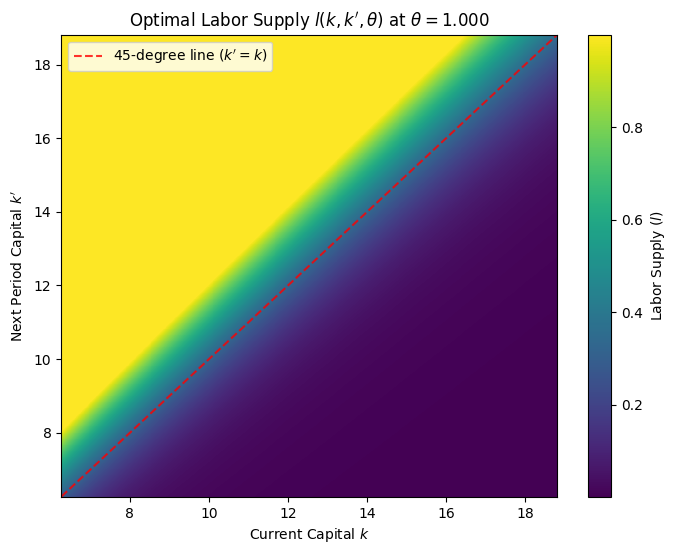

In [13]:
theta_idx = n_theta_grid // 2
theta_val = theta_grid[theta_idx]
l_slice = l_star[:, :, theta_idx].T

fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(k_grid, k_grid, l_slice)
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Labor Supply ($l$)")

ax.set_title(f"Optimal Labor Supply $l(k, k',\\theta)$ at $\\theta = {theta_val:.3f}$")
ax.set_xlabel("Current Capital $k$")
ax.set_ylabel("Next Period Capital $k'$")
ax.plot([k_grid.min(), k_grid.max()], [k_grid.min(), k_grid.max()], color="red", linestyle="--", alpha=0.8, label="45-degree line ($k'=k$)")
ax.legend()
plt.show()

---

Then let's fix a $k$ and visualize the optimal labor supply.

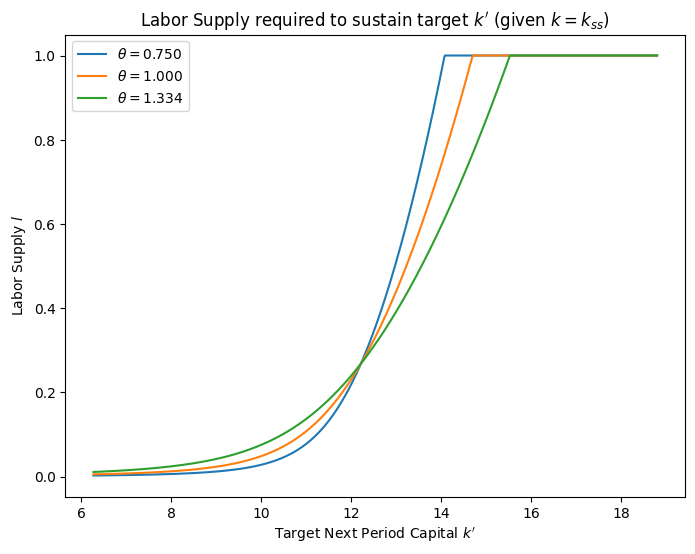

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
k_idx = jnp.abs(k_grid - k_ss).argmin()
theta_indices = [0, n_theta_grid // 2, n_theta_grid - 1]

for t_idx in theta_indices:
    theta_val = theta_grid[t_idx]
    l_slice = l_star[k_idx, :, t_idx]
    ax.plot(k_grid, l_slice, label=f"$\\theta = {theta_val:.3f}$")

ax.set_xlabel(r"Target Next Period Capital $k'$")
ax.set_ylabel(r"Labor Supply $l$")
ax.set_title(r"Labor Supply required to sustain target $k'$ (given $k=k_{ss}$)")
ax.legend()
plt.show()

## Value Function Iteration II
Now we can implement the $B$ function.

In [15]:
@jax.jit
def B(i_k, i_k_p, i_theta, V, params, sizes, arrays, l_star):
    """
    Bellman operator for the value function iteration step.

    Computes the right-hand side of the Bellman equation for a given
    (current capital index, next-period capital index, theta index).
    """
    beta, a, sigma, alpha, delta = params
    k_grid, theta_grid, Pi, p = arrays

    k, k_p, theta = k_grid[i_k], k_grid[i_k_p], theta_grid[i_theta]
    l = l_star[i_k, i_k_p, i_theta]
    c = theta * (k**alpha) * (l ** (1 - alpha)) + (1 - delta) * k - k_p

    EV = Pi[i_theta, :] @ V[i_k_p, :]
    return jnp.where(c > 0, u(c, l, sigma=sigma, a=a) + beta * EV, -jnp.inf)

Then we can vectorize the function over $k,\theta,k'$:

In [16]:
B_1 = jax.vmap(B, in_axes=(None, None, 0, None, None, None, None, None))
B_2 = jax.vmap(B_1, in_axes=(None, 0, None, None, None, None, None, None))
B_vmap = jax.vmap(B_2, in_axes=(0, None, None, None, None, None, None, None))

## Value Function Iteration III
Now we can implement the $T$ function.

In [17]:
@jax.jit
def T(V, params, sizes, arrays, l_star):
    """
    Computes the Bellman update (maximization step) for the value function iteration.
    """
    k_grid, theta_grid, Pi, p = arrays
    n_k_grid, n_theta_grid = jnp.size(k_grid), jnp.size(theta_grid)
    k_indices, theta_indices = jnp.arange(n_k_grid), jnp.arange(n_theta_grid)
    B_values = B_vmap(k_indices, k_indices, theta_indices, V, params, sizes, arrays, l_star)
    return jnp.max(B_values, axis=1), jnp.argmax(B_values, axis=1)

We don't need to vectorize $T$ because it's already vectorized over $k,\theta,k'$ by `B_vmap`.

## Value Function Iteration IV
Now we can implement the VFI algorithm.

In [18]:
@jax.jit
def VFI(V0, params, sizes, arrays, l_star, tol=tolv, max_iter=5_000):
    """
    Value Function Iteration using JAX jit and lax.while_loop.

    Args:
        V0: Initial value function.
        params, sizes, arrays, l_star: Model and solution objects.
        tol: Convergence tolerance.
        max_iter: Maximum iterations.

    Returns:
        it: Number of iterations.
        V: Final value function.
        g_k: Policy (index of optimal next k).
        diff: Final convergence metric.
    """

    def body_fun(it_V_g_k_diff):
        """VFI update step."""
        it, V, g_k, diff = it_V_g_k_diff
        V_new, g_k = T(V, params, sizes, arrays, l_star)
        diff = jnp.max(jnp.abs(V_new - V))
        return (it + 1, V_new, g_k, diff)

    def cond_fun(it_V_g_k_diff):
        """Continue while not converged and under max_iter."""
        it, V, g_k, diff = it_V_g_k_diff
        return (diff > tol) & (it < max_iter)

    init = (0, V0, jnp.zeros((n_k_grid, n_theta_grid), dtype=jnp.int64), jnp.inf)
    it, V, g_k, diff = jax.lax.while_loop(
        cond_fun,
        body_fun,
        init_val=init,
    )
    return it, V, g_k, diff

## Value Function Iteration V
Now we can solve the value function and corresponding policy functions.

In [19]:
V0 = jnp.zeros((n_k_grid, n_theta_grid))
start_time = time.time()
it, V, g_k, diff = VFI(V0, params, sizes, arrays, l_star)
V.block_until_ready()
end_time = time.time()
print(f"Time taken to solve for value function: {end_time - start_time:.4f} seconds")
print(f"Number of iterations: {it} with final difference: {diff:.3e}")

Time taken to solve for value function: 9.6130 seconds
Number of iterations: 2796 with final difference: 9.948e-13


:::{.callout-note}
We can see that the value function converges extremely fast (though through a lot of iterations).
:::

Let's look at the value function:

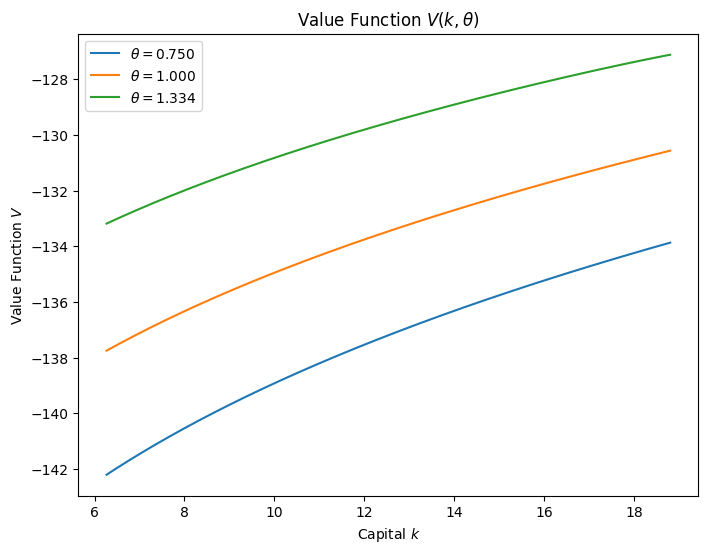

In [20]:
theta_indices = [0, n_theta_grid // 2, n_theta_grid - 1]
plt.figure(figsize=(8, 6))
for theta_idx in theta_indices:
    plt.plot(k_grid, V[:, theta_idx], label=f"$\\theta = {theta_grid[theta_idx]:.3f}$")
plt.xlabel("Capital $k$")
plt.ylabel("Value Function $V$")
plt.title("Value Function $V(k,\\theta)$")
plt.legend()
plt.show()

## Value Function Iteration VI
Now we can recover the policy functions.

In [21]:
gk = k_grid[g_k]

In [22]:
@jax.jit
def get_gl_gc(i_k, i_theta, l_star, params, sizes, arrays, g_k):
    beta, a, sigma, alpha, delta = params
    k_grid, theta_grid, Pi, p = arrays

    i_k_p = g_k[i_k, i_theta]
    k, kp, theta = k_grid[i_k], k_grid[i_k_p], theta_grid[i_theta]
    gl = l_star[i_k, i_k_p, i_theta]
    c = theta * (k**alpha) * (gl ** (1 - alpha)) + (1 - delta) * k - kp
    return jnp.where(jnp.logical_and(gl > 0, gl < 1), gl, jnp.nan), jnp.where(c > 0, c, jnp.nan)

Let's vectorize the function over $k,\theta$:

In [23]:
get_gl_gc_1 = jax.vmap(get_gl_gc, in_axes=(None, 0, None, None, None, None, None))
get_gl_gc_vmap = jax.vmap(get_gl_gc_1, in_axes=(0, None, None, None, None, None, None))

k_indices, theta_indices = jnp.arange(n_k_grid), jnp.arange(n_theta_grid)
gl, gc = get_gl_gc_vmap(k_indices, theta_indices, l_star, params, sizes, arrays, g_k)
gi = gk - (1 - delta) * k_grid[:, jnp.newaxis]
print(f"Shapes: {gk.shape}, {gl.shape}, {gc.shape}, {gi.shape}")

Shapes: (1000, 7), (1000, 7), (1000, 7), (1000, 7)


## Visualize the Policy Functions

Now we can visualize the policy functions.

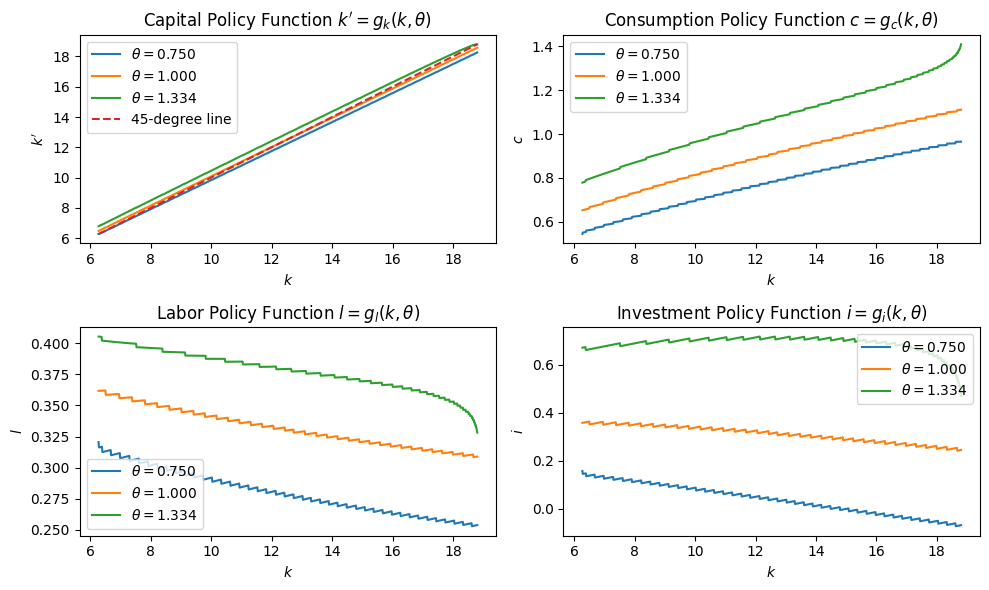

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
ax_k, ax_c = axes[0]
ax_l, ax_i = axes[1]

theta_indices_to_plot = [0, n_theta_grid // 2, n_theta_grid - 1]
labels = [f"$\\theta = {theta_grid[theta_idx]:.3f}$" for theta_idx in theta_indices_to_plot]

for i, t_idx in enumerate(theta_indices_to_plot):
    ax_k.plot(k_grid, gk[:, t_idx], label=labels[i])
ax_k.plot(k_grid, k_grid, linestyle="--", label="45-degree line")
ax_k.set_title("Capital Policy Function $k' = g_k(k, \\theta)$")
ax_k.set_ylabel("$k'$")
ax_k.set_xlabel("$k$")
ax_k.legend()


for i, t_idx in enumerate(theta_indices_to_plot):
    ax_c.plot(k_grid, gc[:, t_idx], label=labels[i])
ax_c.set_title("Consumption Policy Function $c = g_c(k, \\theta)$")
ax_c.set_ylabel("$c$")
ax_c.set_xlabel("$k$")

ax_c.legend()

for i, t_idx in enumerate(theta_indices_to_plot):
    ax_l.plot(k_grid, gl[:, t_idx], label=labels[i])
ax_l.set_title("Labor Policy Function $l = g_l(k, \\theta)$")
ax_l.set_ylabel("$l$")
ax_l.set_xlabel("$k$")
ax_l.legend()

for i, t_idx in enumerate(theta_indices_to_plot):
    ax_i.plot(k_grid, gi[:, t_idx], label=labels[i])
ax_i.set_title("Investment Policy Function $i = g_i(k, \\theta)$")
ax_i.set_ylabel("$i$")
ax_i.set_xlabel("$k$")
ax_i.legend()

plt.tight_layout()
plt.show()

## Simulate the Model

First, we define the simulation kernel. This function takes the current state (capital), the current shock (theta index), and looks up the decision variables.

In [25]:
@jax.jit
def simulate_step(carry, theta_idx, k_grid, gk, gl, gc, gi):
    """
    A single step of the simulation.

    Args:
        carry: The current state (current capital k_t).
        theta_idx: The index of the current productivity shock.
        k_grid, gk, gl, gc, gi: Grids and policy functions.

    Returns:
        new_carry: Next period capital k_{t+1}.
        outputs: Tuple of (k_t, c_t, l_t, i_t, y_t) for this period.
    """
    k_t = carry

    # 1. Retrieve the policy rule column corresponding to the current shock theta
    gk_t = gk[:, theta_idx]
    gl_t = gl[:, theta_idx]
    gc_t = gc[:, theta_idx]
    gi_t = gi[:, theta_idx]

    # 2. Interpolate to find values at current continuous k_t
    k_tp1 = jnp.interp(k_t, k_grid, gk_t)
    l_t = jnp.interp(k_t, k_grid, gl_t)
    c_t = jnp.interp(k_t, k_grid, gc_t)
    i_t = jnp.interp(k_t, k_grid, gi_t)

    # 3. Calculate output (Production function)
    y_t = c_t + i_t

    return k_tp1, (k_t, c_t, l_t, i_t, y_t)

---

## Simulate using `jax.lax.scan`

Now we wrap the scan loop in a function that generates the shocks and runs the simulation.

In [26]:
@jax.jit(static_argnums=1)
def run_simulation(key, T, k0, gk, gl, gc, gi, params, arrays, sizes):
    """
    Simulates the economy for T periods.
    """
    k_grid, theta_grid, Pi, p = arrays

    uniform_draws = jax.random.uniform(key, shape=(T,))

    def simulate_mc(current_idx, draw):
        p_vec = Pi[current_idx, :]
        cdf = jnp.cumsum(p_vec)
        next_idx = jnp.searchsorted(cdf, draw)
        return next_idx, next_idx

    n_theta = Pi.shape[0]
    idx_0 = n_theta // 2

    _, theta_indices = jax.lax.scan(simulate_mc, idx_0, uniform_draws)

    def step_func(carry, theta_idx):
        return simulate_step(carry, theta_idx, k_grid, gk, gl, gc, gi)

    final_k, trajectory = jax.lax.scan(step_func, k0, theta_indices)

    return theta_indices, trajectory

## Understanding `jax.lax.scan`

- In standard Python, we use `for` loops. However, in JAX (under JIT compilation), a standard loop tries to "unroll" (copy-paste) the code for each iteration. 
- If the number of iterations is large, this makes compilation incredibly slow and consumes massive memory.
- `jax.lax.scan` compiles the loop into a single, efficient XLA operation. Its logic is simple: **"Take a step carrying a state, and record the output of that step."**

- The signature generally looks like this:

    ```{.python}
    final_carry, stacked_outputs = jax.lax.scan(f, init, xs)
    ```

1. **`f` (The Function):** The logic for one step: `(carry, input_item) -> (new_carry, output_item)`.
2. **`init` (The Initial Carry):** The starting state.
3. **`xs` (The Sequence):** The data to iterate over (length $T$).

## Run the Simulation

Now we can run the simulation.

In [27]:
# Set simulation parameters
T_sim = 20000
seed = 42
key = jax.random.PRNGKey(seed)
k0 = k_ss  # Start at steady state

# Run
start_time = time.time()
theta_indices, (sim_k, sim_c, sim_l, sim_i, sim_y) = run_simulation(key, T_sim, k0, gk, gl, gc, gi, params, arrays, sizes)
theta_indices.block_until_ready()
end_time = time.time()
print(f"Time taken to run the simulation: {end_time - start_time:.4f} seconds")
sim_theta = theta_grid[theta_indices]
print(f"Simulation shape: {sim_k.shape}")

Time taken to run the simulation: 0.1327 seconds
Simulation shape: (20000,)


The simulation is again very fast.

## Understanding Random Numbers in JAX

**NumPy is "stateful", while JAX is "stateless".**

* **NumPy (Traditional Approach):**
    - When you call `np.random.seed(42)`, NumPy modifies a **global variable** in the background. Every time you call `np.random.uniform()`, it reads and updates this global state.
    * *Drawback*: Managing such global side effects is very difficult and inefficient in parallel computation or under JIT compilation.

* **JAX (Functional Approach):**
    - JAX has no global state. Its random number generator is just a **pure function**.
    - Input: a key.
    - Output: random numbers.
    - **Rule**: As long as the input key is the same, the output random numbers will always be exactly the same.

---


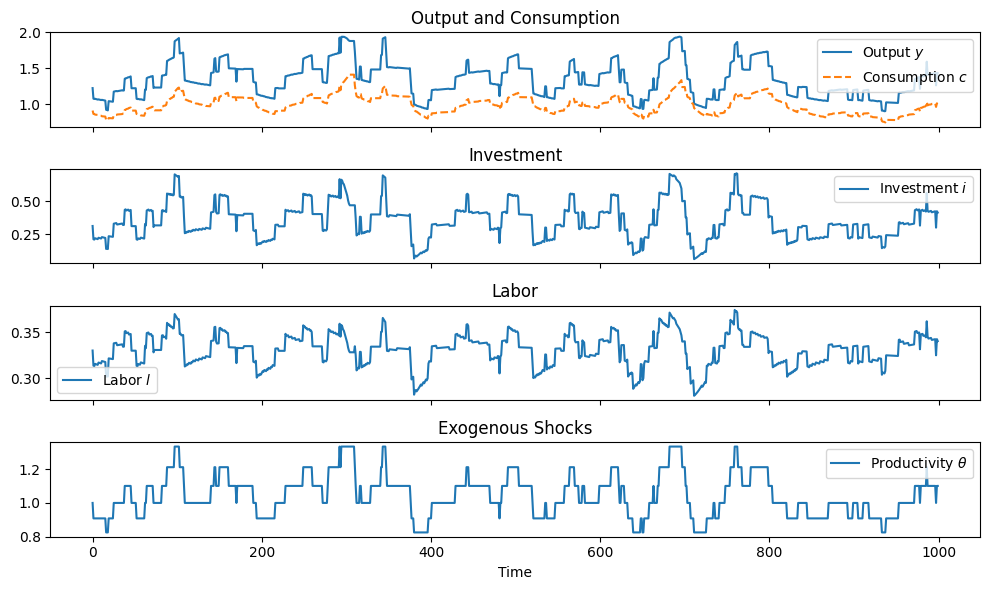

In [28]:
T_plot = jnp.int64(0.05 * T_sim)

time_axis = jnp.arange(T_plot)
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 6))

# Output and Consumption
axes[0].plot(time_axis, sim_y[:T_plot], label="Output $y$")
axes[0].plot(time_axis, sim_c[:T_plot], label="Consumption $c$", linestyle="--")
axes[0].set_title("Output and Consumption")
axes[0].legend()

# Investment
axes[1].plot(time_axis, sim_i[:T_plot], label="Investment $i$")
axes[1].set_title("Investment")
axes[1].legend()

# Labor
axes[2].plot(time_axis, sim_l[:T_plot], label="Labor $l$")
axes[2].set_title("Labor")
axes[2].legend()

# Shocks
axes[3].plot(time_axis, sim_theta[:T_plot], label="Productivity $\\theta$")
axes[3].set_title("Exogenous Shocks")
axes[3].set_xlabel("Time")
axes[3].legend()

plt.tight_layout()
plt.show()

## References